[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lynchaos/hybrid-bioprocess-lab/blob/main/notebooks/hybrid_bioprocess_analysis.ipynb)

# Hybrid Bioprocess ML: Reproducible Synthetic Study

This notebook demonstrates a constrained hybrid model for fed-batch mammalian cell culture. It is a portfolio-quality synthetic study: results are useful for evaluating methodology, but they are **not** evidence from an industrial process.

In [ ]:
# Colab setup: clone the public repo and install the package.
# This cell is a no-op outside Colab (e.g. local Jupyter, VS Code), where the
# package is already importable via an editable install or the sys.path
# fallback in the next cell.
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/lynchaos/hybrid-bioprocess-lab.git"
    REPO_DIR = "hybrid-bioprocess-lab"

    if not os.path.exists(REPO_DIR):
        !git clone --depth 1 {REPO_URL}
    %cd {REPO_DIR}
    %pip install -q -e . matplotlib
    print("Colab environment ready:", os.getcwd())
else:
    print("Not running on Colab; skipping clone/install.")

## Study Contract

The learned component is a bounded multiplier on mechanistic growth. Every candidate is evaluated on held-out batches and scientific constraints are gates, not penalty terms. The later sections quantify variation across predeclared synthetic seeds and bootstrap-resampled training batches.

In [23]:
from pathlib import Path

import importlib

import sys



import matplotlib.pyplot as plt

import numpy as np



project_root = Path.cwd().resolve().parent

if not (project_root / "src").exists():

    project_root = Path.cwd().resolve()

sys.path.insert(0, str(project_root / "src"))



import hybridbio



importlib.reload(hybridbio)

evaluation_module = importlib.reload(importlib.import_module("hybridbio.evaluation"))



from hybridbio import (

    EnsembleConfig,

    KineticParameters,

    PureMLConfig,

    StudyConfig,

    TrainingConfig,

    audit_correction,

    build_manifest,

    generate_dataset,

    run_repeated_study,

    train_and_evaluate,

    train_bootstrap_ensemble,

    train_pure_ml_trajectory,

    train_test_split_batches,

)

from hybridbio.evaluation import evaluate

from hybridbio.mechanistic import STATE_NAMES



params = KineticParameters()

training_config = TrainingConfig(seed=7)

print(f"Project root: {project_root}")


Project root: /Users/kemal/Desktop/codes/ml/hybrid-bioprocess-lab


## Held-Out Baseline Comparison

Data are split by whole batch, never by timepoint. This prevents trajectory leakage between training and test partitions.

In [24]:
batches = generate_dataset(n_batches=18, seed=7)
train_batches, test_batches = train_test_split_batches(batches, n_test=4)
hybrid, hybrid_report, baseline_report = train_and_evaluate(
    train_batches,
    test_batches,
    p=params,
    cfg=training_config,
)

print(baseline_report.render())
print()
print(hybrid_report.render())
print()
print(
    "Hybrid minus baseline NRMSE: "
    f"{hybrid_report.metrics['nrmse_mean'] - baseline_report.metrics['nrmse_mean']:+.4f}"
)

Evaluation over 4 batch(es)
----------------------------------------------
  final_titre_rel_err            0.1514
  nrmse_L                        0.0718
  nrmse_P                        0.0725
  nrmse_S                        0.3034
  nrmse_Xv                       0.1200
  nrmse_mean                     0.1419
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PASS

Evaluation over 4 batch(es)
----------------------------------------------
  final_titre_rel_err            0.1109
  nrmse_L                        0.0546
  nrmse_P                        0.0447
  nrmse_S                        0.2127
  nrmse_Xv                       0.0881
  nrmse_mean                     0.1000
----------------------------------------------
  scientific constraints              0 violation(s)
  verdict                          PASS

Hybrid minus baseline NRMSE: -0.0419


## Trajectory Inspection

A single held-out batch makes the model behavior inspectable. Accuracy is reported alongside constraints; neither replaces the other.

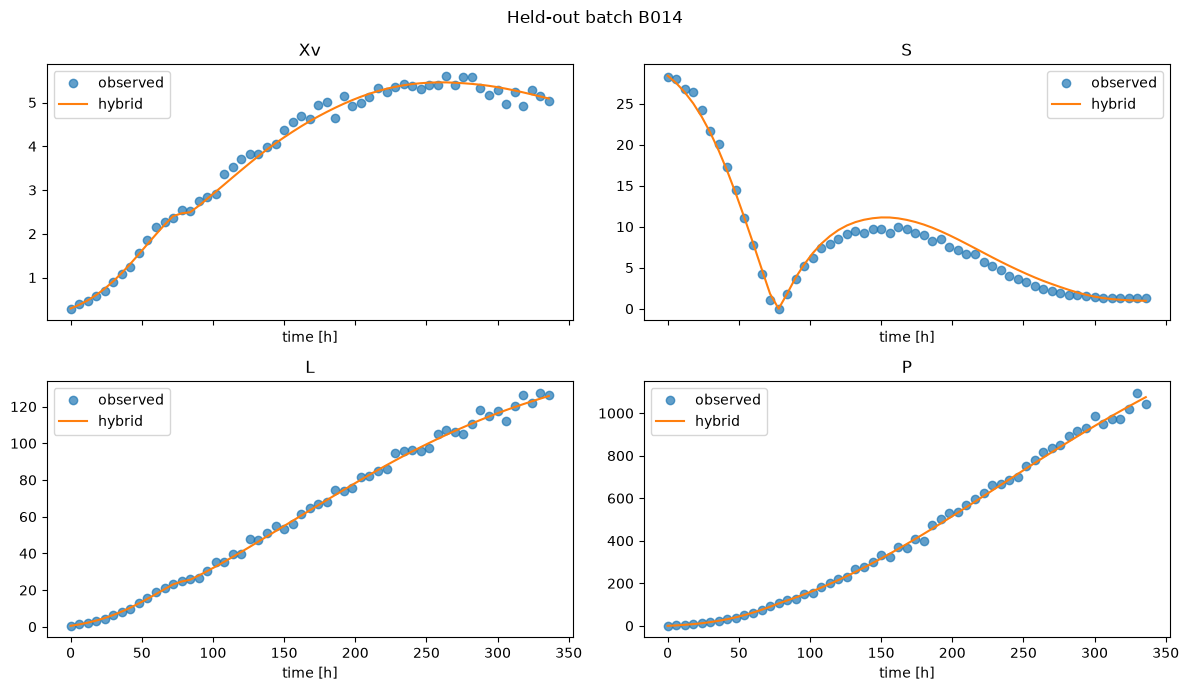

In [25]:
batch = test_batches[0]
model_for_batch = hybrid.__class__(
    params=hybrid.params,
    feed=batch.feed,
    correction=hybrid.correction,
    t_end_h=hybrid.t_end_h,
    dt_h=hybrid.dt_h,
)
t_pred, y_pred = model_for_batch.simulate(batch.y0)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for axis, state in zip(axes.ravel(), ("Xv", "S", "L", "P"), strict=True):
    state_index = STATE_NAMES.index(state)
    axis.plot(batch.t, batch.Y[:, state_index], "o", label="observed", alpha=0.7)
    axis.plot(t_pred, y_pred[:, state_index], label="hybrid")
    axis.set_title(state)
    axis.set_xlabel("time [h]")
    axis.legend()
fig.suptitle(f"Held-out batch {batch.batch_id}")
fig.tight_layout()

## Repeated-Seed Evidence

A single favorable split is not enough. The study repeats paired, held-out comparisons over predeclared seeds and computes a bootstrap confidence interval from batch-level deltas. A result counts as an improvement only when every run is admissible and the complete interval is below zero.

In [26]:
study_result = run_repeated_study(
    StudyConfig(
        seeds=(7, 17, 29),
        n_batches=12,
        n_test=3,
        n_bootstrap=500,
        bootstrap_seed=7,
    ),
    params=params,
    training_config=training_config,
)
ci = study_result.nrmse_delta
print(f"Paired NRMSE delta: {ci.estimate:+.4f}")
print(f"{ci.confidence:.0%} bootstrap CI: [{ci.lower:+.4f}, {ci.upper:+.4f}]")
print(f"Admissible runs: {study_result.admissible_runs}/{study_result.n_runs}")
print(f"Evidence supports improvement: {study_result.candidate_improves}")

Paired NRMSE delta: -0.0271
95% bootstrap CI: [-0.0377, -0.0167]
Admissible runs: 3/3
Evidence supports improvement: True


## Direct Pure-ML Comparator



The comparator receives only time, initial conditions, and feed settings. It does not see future measured states and it does not evolve a mechanistic mass balance. It is trained on exactly the same whole-batch training partition and judged by the same held-out NRMSE and scientific constraint gate as the hybrid model. This is a benchmark, not a target to make scientifically admissible by post-processing.


In [27]:
pure_ml = train_pure_ml_trajectory(

    train_batches,

    params=params,

    config=PureMLConfig(seed=7),

    t_end_h=training_config.t_end_h,

)

pure_ml_report = evaluate(pure_ml, test_batches)



print(pure_ml_report.render())

print()

print(

    "Hybrid minus pure-ML NRMSE: "

    f"{hybrid_report.metrics['nrmse_mean'] - pure_ml_report.metrics['nrmse_mean']:+.4f}"

)

print(

    "Pure-ML scientific admissibility: "

    f"{pure_ml_report.constraints_ok} ({pure_ml_report.n_violations()} violation(s))"

)


Evaluation over 4 batch(es)
----------------------------------------------
  final_titre_rel_err            0.0820
  nrmse_L                        0.0545
  nrmse_P                        0.0426
  nrmse_S                        0.1975
  nrmse_Xv                       0.0767
  nrmse_mean                     0.0928
----------------------------------------------
  scientific constraints              1 violation(s)
  verdict                          FAIL

    ! [volume_decrease] volume decreased in a feed-only process (worst=-0.004501)

Hybrid minus pure-ML NRMSE: +0.0072
Pure-ML scientific admissibility: False (1 violation(s))


## Bootstrap Trajectory Uncertainty

The ensemble resamples whole training batches, preserving within-batch correlation. Its quantiles express variability caused by the available synthetic data, not a safety guarantee for real manufacturing.

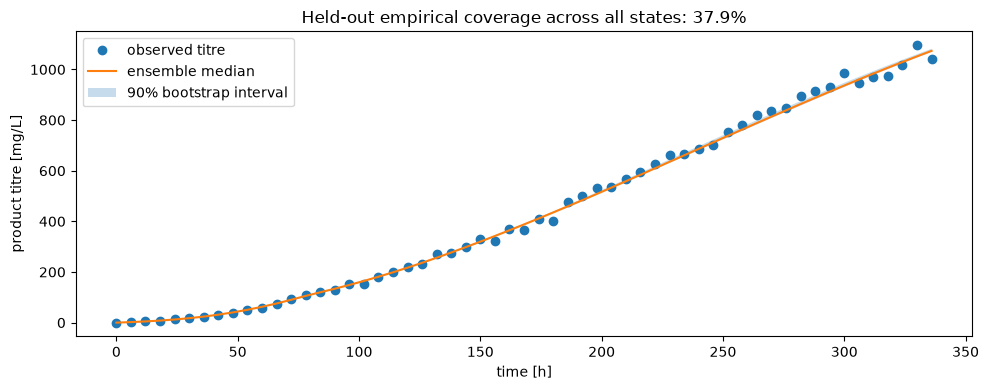

In [28]:
ensemble = train_bootstrap_ensemble(
    train_batches,
    params=params,
    training_config=training_config,
    config=EnsembleConfig(n_members=6, seed=7),
)
interval = ensemble.predict(batch.y0, batch.feed)
titre_index = STATE_NAMES.index("P")
coverage = interval.empirical_coverage(batch.Y)

fig, axis = plt.subplots(figsize=(10, 4))
axis.plot(batch.t, batch.Y[:, titre_index], "o", label="observed titre")
axis.plot(interval.t, interval.median[:, titre_index], label="ensemble median")
axis.fill_between(
    interval.t,
    interval.lower[:, titre_index],
    interval.upper[:, titre_index],
    alpha=0.25,
    label="90% bootstrap interval",
)
axis.set(xlabel="time [h]", ylabel="product titre [mg/L]")
axis.set_title(f"Held-out empirical coverage across all states: {coverage:.1%}")
axis.legend()
fig.tight_layout()

## Lineage and Correction Audit



A model result is only reviewable if the split and decision can be reconstructed. The manifest records source identity, exact train/test batch IDs, model configuration, feature contract, metrics, scientific-gate status, Git revision, and runtime environment. The correction audit is deliberately descriptive: it shows multiplier range and local one-feature perturbation effects, not causal feature importance.


In [29]:
manifest = build_manifest(

    data_source="synthetic-fed-batch",

    dataset_id="seed-7",

    train_batches=train_batches,

    test_batches=test_batches,

    params=params,

    candidate_report=hybrid_report,

    baseline_report=baseline_report,

    training_config={"seed": 7, "backend": "sklearn"},

)

correction_audit = audit_correction(hybrid, train_batches)



print(f"Promotion decision: {manifest.promotion_decision}")

print(f"Reason: {manifest.promotion_reason}")

print(f"Train batches: {', '.join(manifest.train_batch_ids)}")

print(f"Held-out batches: {', '.join(manifest.test_batch_ids)}")

print(

    "Correction multiplier range: "

    f"{correction_audit.correction_min:.3f} to {correction_audit.correction_max:.3f}"

)

for name, effect in correction_audit.feature_effects.items():

    print(f"  {name:>12}: {effect:.5f}")


Promotion decision: eligible_for_registration
Reason: scientific constraints passed and candidate improved the baseline
Train batches: B000, B001, B002, B003, B004, B005, B006, B007, B008, B009, B010, B011, B012, B013
Held-out batches: B014, B015, B016, B017
Correction multiplier range: 0.500 to 1.258
             S: 0.27027
             L: 0.57728
            Xv: 0.08517
     S_over_Ks: 0.16600
     L_over_Ki: 0.03050
       mu_mech: 0.23135
        t_norm: 0.10972


## Data and Workflow Boundaries

External CSV exports enter through `hybridbio.ingestion.load_batches_csv()`, which validates explicit units, finite values, monotonic timestamps, non-negative state values, and stable per-batch feed settings. The Optuna and Ray workflows prune or exclude scientifically inadmissible trials rather than treating a violation as a worse numeric score.

Before process decisions, replace this synthetic plant with versioned real data, prespecify stress scenarios and acceptance criteria, calibrate intervals on external batches, and retain audit artifacts for every promoted model.